In [1]:
from src.measure_ir import *
import matplotlib.pyplot as plt
import numpy as np
from src.audio_device import AudioDevice
import soundfile as sf
from src.real_time import RealtimeFxLMS

In [2]:
arthur, fs = sf.read('data/arthur_clip_48k.wav')
ad = AudioDevice(fs)

In [3]:
error_ir, _ = measure_ir(ad)
error_ir_stream, _ = measure_ir_stream(ad, block_size=64)

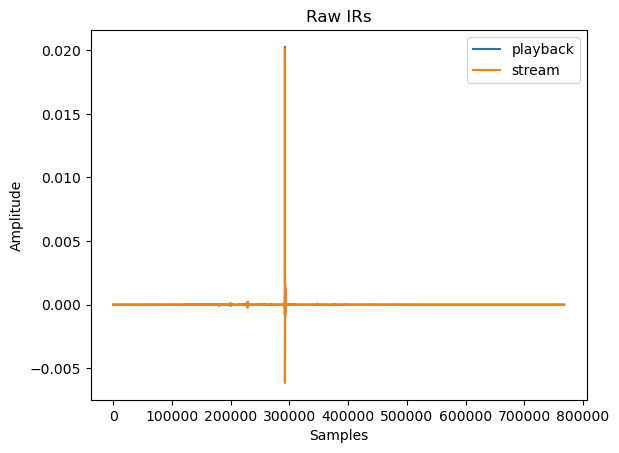

In [4]:
plt.plot(error_ir, label="playback")
plt.plot(error_ir_stream, label="stream")

plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.title('Raw IRs')
plt.legend()
plt.show()

In [5]:
ir_len = 128
panel_to_err_cm = 9
filter_order = 2 * ir_len

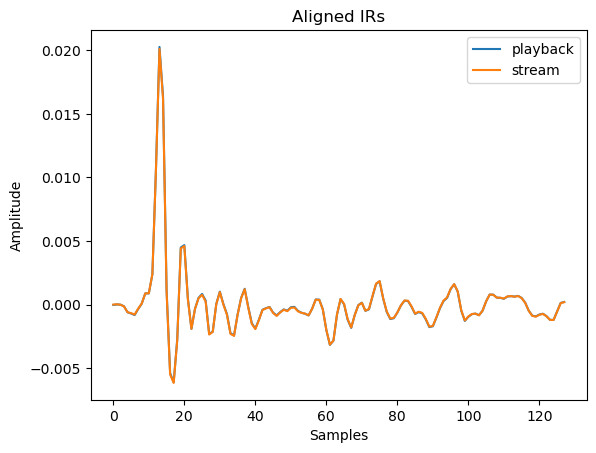

In [6]:
panel_ir = align_ir_by_distance(error_ir, panel_to_err_cm, ir_len)
panel_ir_stream = align_ir_by_distance(error_ir_stream, panel_to_err_cm, ir_len)

plt.plot(panel_ir, label="playback")
plt.plot(panel_ir_stream, label="stream")

plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.title('Aligned IRs')
plt.legend()
plt.show()

In [7]:
arthur_repeated = np.tile(arthur, 1)
arthur.shape, arthur_repeated.shape

((238834,), (238834,))

In [8]:
rt = RealtimeFxLMS(
    ad,
    source=arthur_repeated,
    ir=panel_ir,
    block_size=64,
    filter_order=filter_order,
)
error_nc, cancel_nc, *_ = rt.run(source_gain=1.0, cancel_gain=0.0)

In [9]:
lag = rt.empirical_delay()

Lag from cross-correlation: 4470
Delay from device: 4312


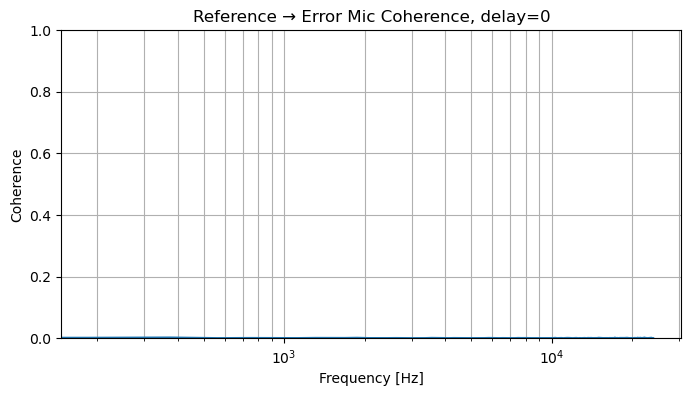

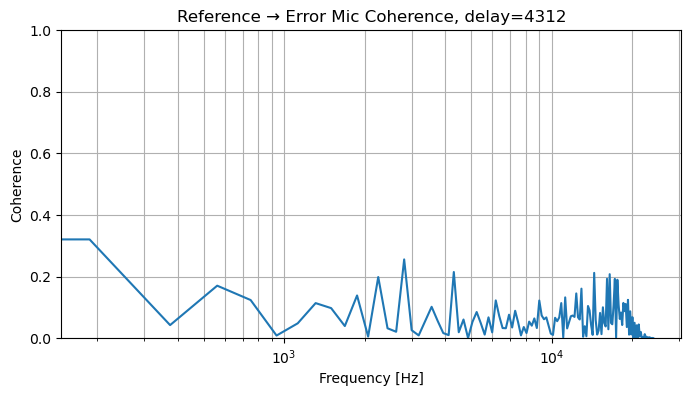

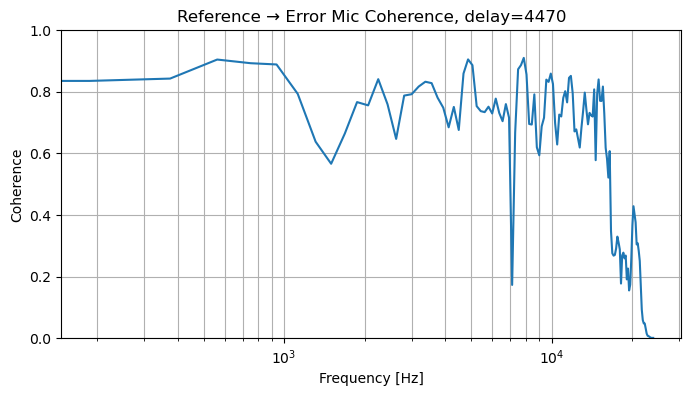

In [10]:
rt.plot_coherence(delay=0)
rt.plot_coherence(delay=4312)
rt.plot_coherence(delay=lag)


In [26]:
arthur_repeated = np.tile(arthur, 1)
arthur.shape, arthur_repeated.shape
rt = RealtimeFxLMS(
    ad,
    source=arthur_repeated,
    ir=panel_ir,
    block_size=64,
    filter_order=ir_len * 3,
)
error_nc, cancel_nc, *_ = rt.run(source_gain=1.0, cancel_gain=0.0)
lag = rt.empirical_delay()
rms_nc = np.sqrt(np.mean(error_nc**2))
print(rms_nc)

Lag from cross-correlation: 4475
Delay from device: 4312
0.0014881568


In [27]:
delays = range(0, 257, 8)
c_gains = [0.05, 0.1, 0.15, 0.2]
signs = [1.0, -1.0]

for d in delays:
    for c_gain in c_gains:
        for sign in signs:
            rt.reset(0)
            rt.w[d] = sign

            error, cancel, *_ = rt.run(
                source_gain=1.0,
                cancel_gain=c_gain,
                fx=False,
                nlms=False,
                clean_source=True,
                step_fn=0,
                leak=0,
                max_norm=0.0,
            )

            rms = np.sqrt(np.mean(error**2))
            print('d:', d, 'c_gain:', c_gain, sign, 'sign', 'rms:', rms, 'db_redux:', 20*np.log10(rms / rms_nc))

d: 0 c_gain: 0.05 1.0 sign rms: 0.0015114282 db_redux: 0.13477573
d: 0 c_gain: 0.05 -1.0 sign rms: 0.0014806876 db_redux: -0.043705367
d: 0 c_gain: 0.1 1.0 sign rms: 0.0015498389 db_redux: 0.35275674
d: 0 c_gain: 0.1 -1.0 sign rms: 0.0014901427 db_redux: 0.011582974
d: 0 c_gain: 0.15 1.0 sign rms: 0.0015795875 db_redux: 0.51789916
d: 0 c_gain: 0.15 -1.0 sign rms: 0.0015566692 db_redux: 0.39095247
d: 0 c_gain: 0.2 1.0 sign rms: 0.0016228256 db_redux: 0.75246304
d: 0 c_gain: 0.2 -1.0 sign rms: 0.0017712621 db_redux: 1.5126823
d: 8 c_gain: 0.05 1.0 sign rms: 0.0014867937 db_redux: -0.007959439
d: 8 c_gain: 0.05 -1.0 sign rms: 0.0015050104 db_redux: 0.0978159
d: 8 c_gain: 0.1 1.0 sign rms: 0.0014998252 db_redux: 0.067838304
d: 8 c_gain: 0.1 -1.0 sign rms: 0.0015398137 db_redux: 0.29638934
d: 8 c_gain: 0.15 1.0 sign rms: 0.001492642 db_redux: 0.026138593
d: 8 c_gain: 0.15 -1.0 sign rms: 0.0016424479 db_redux: 0.85685796
d: 8 c_gain: 0.2 1.0 sign rms: 0.0015022109 db_redux: 0.08164358
d: 8 c

d: 104 c_gain: 0.2 1 sign rms: 0.0012206428 db_redux: -1.7212023


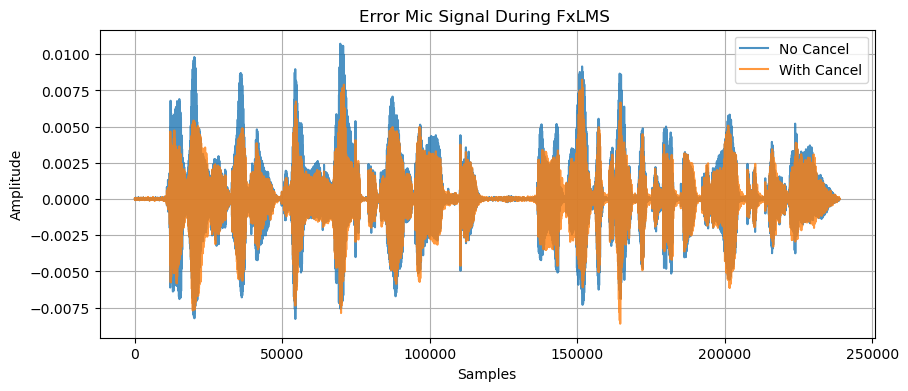

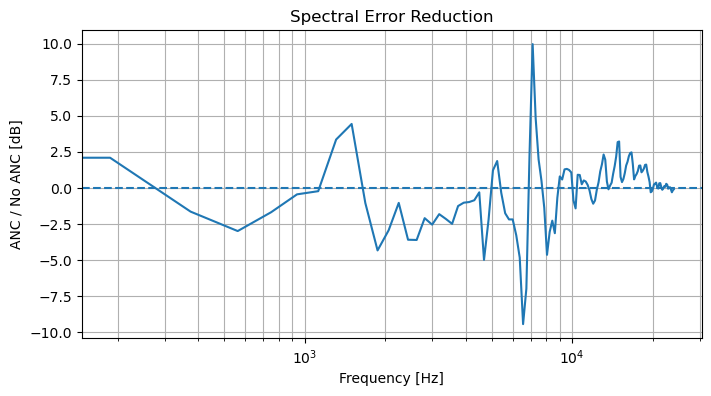

In [32]:
d = 104
sign = 1
c_gain = 0.2

rt.reset(0)
rt.w[d] = sign

error, cancel, *_ = rt.run(
    source_gain=1.0,
    cancel_gain=c_gain,
    fx=False,
    nlms=False,
    clean_source=True,
    step_fn=0,
    leak=0,
    max_norm=0.0,
)

rms = np.sqrt(np.mean(error**2))
print('d:', d, 'c_gain:', c_gain, sign, 'sign', 'rms:', rms, 'db_redux:', 20*np.log10(rms / rms_nc))
rt.plot_error_mic(error_nc)
rt.plot_error_reduction(error_nc)

In [37]:
arthur_repeated = np.tile(arthur, 20)
arthur.shape, arthur_repeated.shape
rt = RealtimeFxLMS(
    ad,
    source=arthur_repeated,
    ir=panel_ir,
    block_size=64,
    filter_order=ir_len * 3,
)
error_nc, cancel_nc, *_ = rt.run(source_gain=1.0, cancel_gain=0.0)
lag = rt.empirical_delay()
rms_nc = np.sqrt(np.mean(error_nc**2))
print(rms_nc)

Lag from cross-correlation: 4470
Delay from device: 4312
0.0014883195


rms: 0.001087843 db_redux: -2.7225993


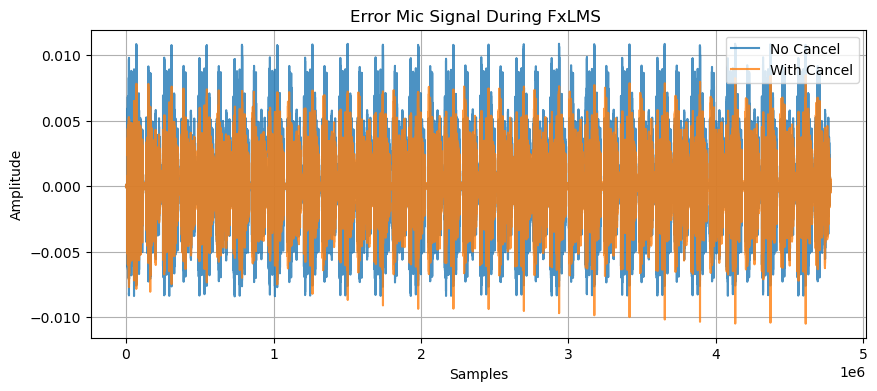

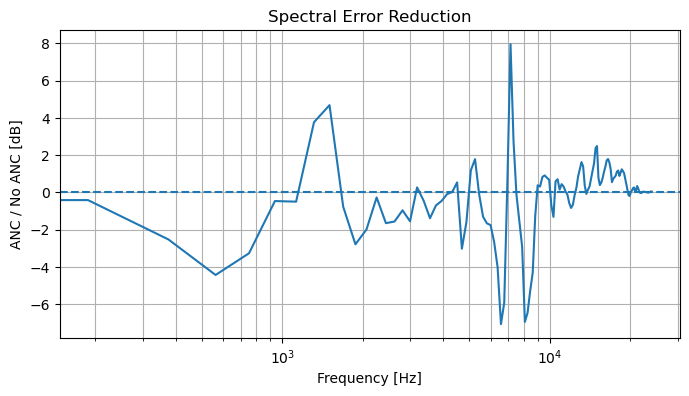

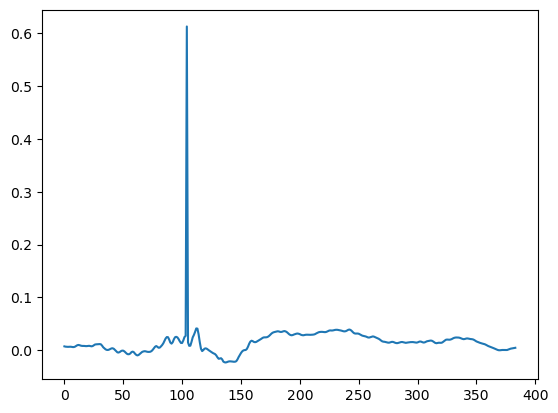

In [38]:
d = 104
sign = 1
c_gain = 0.2

rt.reset(4312)
rt.w[d] = sign

error, cancel, *_ = rt.run(
    source_gain=1.0,
    cancel_gain=c_gain,
    fx=True,
    nlms=True,
    clean_source=True,
    step_fn=1e-4,
    leak=1e-7,
    max_norm=1.0,
)

rms = np.sqrt(np.mean(error**2))
print('rms:', rms, 'db_redux:', 20*np.log10(rms / rms_nc))
rt.plot_error_mic(error_nc)
rt.plot_error_reduction(error_nc)
plt.plot(rt.w)

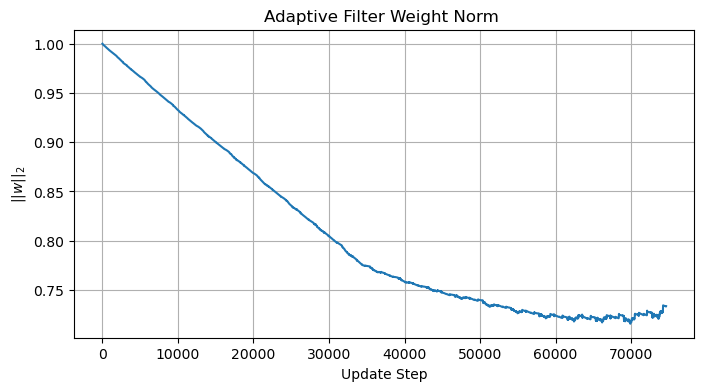

In [39]:
rt.plot_w_norm()

rms: 0.0012641595 db_redux: -1.417886


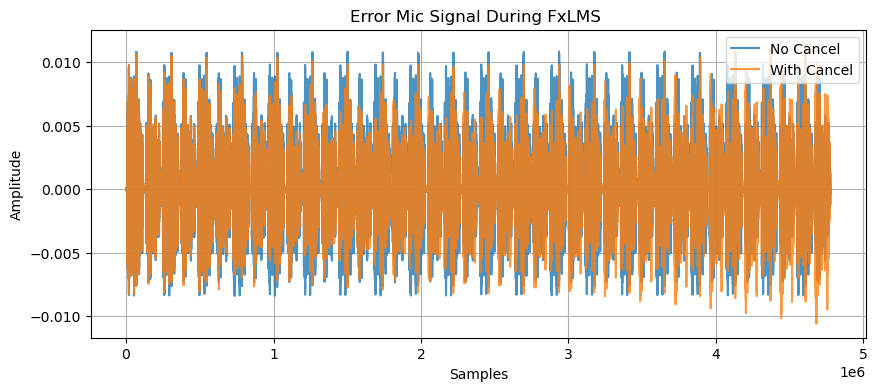

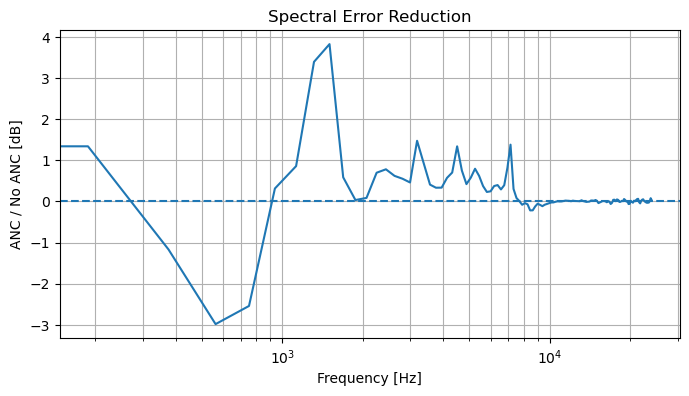

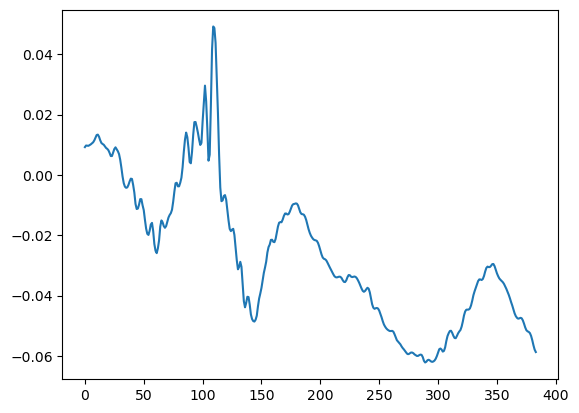

In [40]:
d = 104
sign = 1
c_gain = 0.2

rt.reset(4312)
# rt.w[d] = sign # start from zeros

error, cancel, *_ = rt.run(
    source_gain=1.0,
    cancel_gain=c_gain,
    fx=True,
    nlms=True,
    clean_source=True,
    step_fn=1e-4,
    leak=1e-7,
    max_norm=1.0,
)

rms = np.sqrt(np.mean(error**2))
print('rms:', rms, 'db_redux:', 20*np.log10(rms / rms_nc))
rt.plot_error_mic(error_nc)
rt.plot_error_reduction(error_nc)
plt.plot(rt.w)

In [67]:
arthur_repeated = np.tile(arthur, 50)
arthur.shape, arthur_repeated.shape
rt = RealtimeFxLMS(
    ad,
    source=arthur_repeated,
    ir=panel_ir,
    block_size=64,
    filter_order=ir_len * 16,
)
error_nc, cancel_nc, *_ = rt.run(source_gain=1.0, cancel_gain=0.0)
lag = rt.empirical_delay()
rms_nc = np.sqrt(np.mean(error_nc**2))
print(rms_nc)

Lag from cross-correlation: 4470
Delay from device: 4312
0.0014560937


rms: 0.0010817149 db_redux: -2.5815306


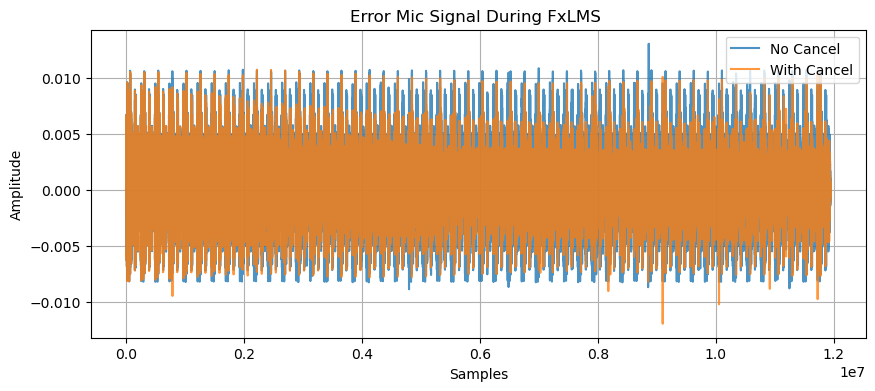

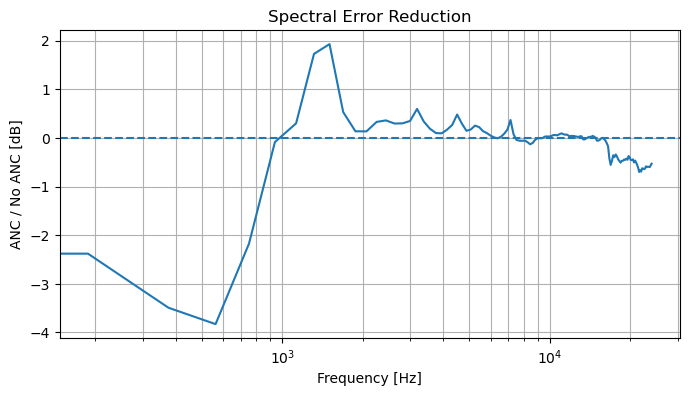

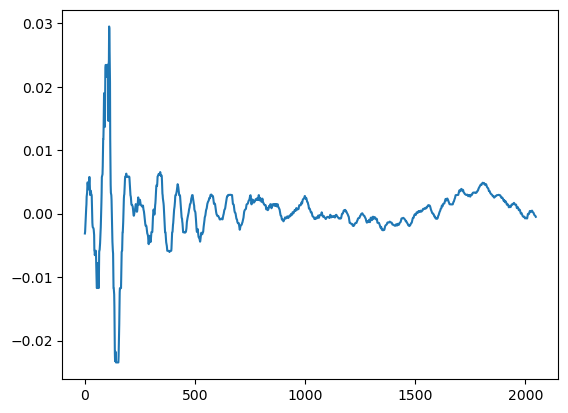

In [68]:
rt.reset(4312)

error, cancel, *_ = rt.run(
    source_gain=1.0,
    cancel_gain=.2,
    fx=True,
    nlms=True,
    clean_source=True,
    step_fn=1e-4,
    leak=1e-7,
    max_norm=1.0,
)

rms = np.sqrt(np.mean(error**2))
print('rms:', rms, 'db_redux:', 20*np.log10(rms / rms_nc))
rt.plot_error_mic(error_nc)
rt.plot_error_reduction(error_nc)
plt.plot(rt.w)

rms: 0.0009511641 db_redux: -3.6986775


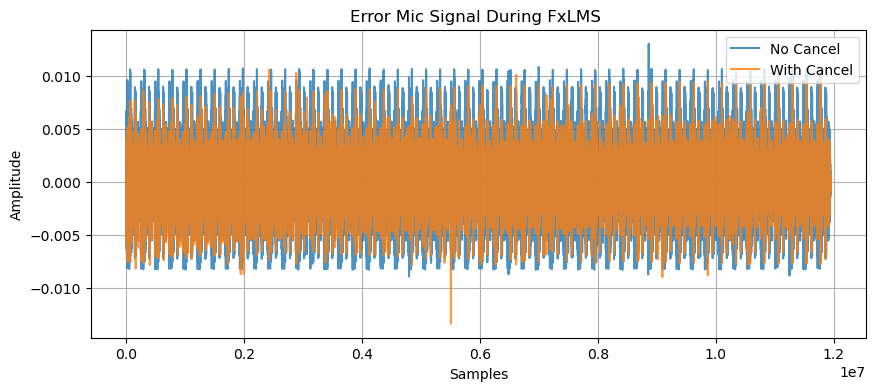

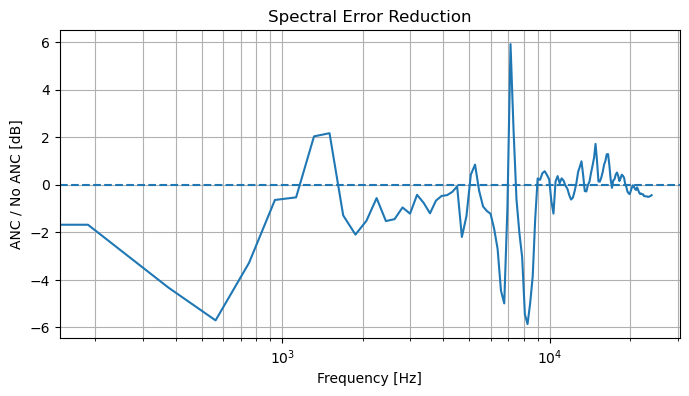

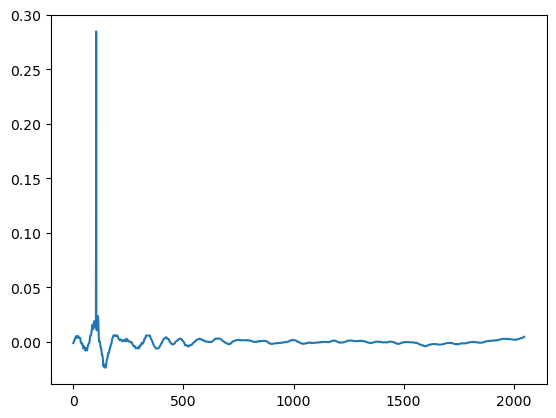

In [69]:
d = 104
sign = 1.0

rt.reset(4312)
rt.w[d] = sign

error, cancel, *_ = rt.run(
    source_gain=1.0,
    cancel_gain=.2,
    fx=True,
    nlms=True,
    clean_source=True,
    step_fn=1e-4,
    leak=1e-7,
    max_norm=1.0,
)

rms = np.sqrt(np.mean(error**2))
print('rms:', rms, 'db_redux:', 20*np.log10(rms / rms_nc))
rt.plot_error_mic(error_nc)
rt.plot_error_reduction(error_nc)
plt.plot(rt.w)